In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [3]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [4]:
len(words)

32033

In [217]:
chars = sorted(list(set(''.join(words))))
stoi = {s: i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [218]:
block_size = 3
X, Y = [], []
for w in words:
    context = [0] * block_size
    for ch in w + ".":
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)

In [219]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [220]:
def build_dataset(words):
    block_size = 3
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + ".":
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


In [221]:
X

tensor([[ 0,  0,  0],
        [ 0,  0, 25],
        [ 0, 25, 21],
        ...,
        [15, 22,  1],
        [22,  1, 14],
        [ 1, 14,  9]])

In [222]:
Y

tensor([25, 21,  8,  ..., 14,  9,  0])

In [223]:
C = torch.randn((27, 2))

In [224]:
emb = C[X]

In [225]:
emb.shape

torch.Size([228146, 3, 2])

In [226]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [227]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
h

tensor([[-0.9998, -1.0000, -0.0873,  ..., -0.9131, -0.9653, -0.9813],
        [-0.9999, -0.9989,  0.6338,  ..., -0.8420, -0.9999, -0.9812],
        [-0.9975, -0.8415, -0.9997,  ..., -0.9996,  0.9117,  0.1060],
        ...,
        [ 0.2058,  0.9996, -1.0000,  ..., -0.9999,  1.0000,  0.9372],
        [ 0.9712, -0.1605,  1.0000,  ...,  0.9997,  0.8736, -0.9995],
        [-1.0000,  0.9823,  0.9128,  ..., -0.9997, -0.9999,  0.9915]])

In [228]:
h.shape

torch.Size([228146, 100])

In [229]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [230]:
logits = h @ W2 + b2
logits.shape

torch.Size([228146, 27])

In [231]:
logits

tensor([[ 16.4766,  -4.8327,   8.6404,  ...,  -2.4474,  -7.9196,  25.8563],
        [ 28.0003,  -3.5951,   6.8729,  ..., -11.3250, -12.9781,  26.2939],
        [  9.9879,  -7.7853,   8.5677,  ..., -13.9743,  -3.6090,   4.3367],
        ...,
        [-11.9637, -12.2078,  -1.1587,  ..., -13.1797,   5.9159, -12.2616],
        [ -6.4209,  -3.9372, -14.4255,  ...,   8.3532,   3.9715,  -6.4474],
        [ -4.5151,   0.7312, -10.1088,  ...,  -1.8814,  -2.6851,   8.0810]])

In [232]:
counts = logits.exp()
prob = counts / counts.sum(1, keepdim=True)
prob.shape

torch.Size([228146, 27])

In [233]:
loss = -prob[torch.arange(228146), Y].log().mean()
loss

tensor(19.3697)

In [292]:
g = torch.Generator().manual_seed(42)
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)

In [293]:
parameters = [C, W1, b1, W2, b2]
parameters

[tensor([[ 1.9269e+00,  1.4873e+00,  9.0072e-01, -2.1055e+00,  6.7842e-01,
          -1.2345e+00, -4.3067e-02, -1.6047e+00, -7.5214e-01,  1.6487e+00],
         [-3.9248e-01, -1.4036e+00, -7.2788e-01, -5.5943e-01, -7.6884e-01,
           7.6245e-01,  1.6423e+00, -1.5960e-01, -4.9740e-01,  4.3959e-01],
         [-7.5813e-01,  1.0783e+00,  8.0080e-01,  1.6806e+00,  1.2791e+00,
           1.2964e+00,  6.1047e-01,  1.3347e+00, -2.3162e-01,  4.1759e-02],
         [-2.5158e-01,  8.5986e-01, -1.3847e+00, -8.7124e-01, -2.2337e-01,
           1.7174e+00,  3.1888e-01, -4.2452e-01,  3.0572e-01, -7.7459e-01],
         [-1.5576e+00,  9.9564e-01, -8.7979e-01, -6.0114e-01, -1.2742e+00,
           2.1228e+00, -1.2347e+00, -4.8791e-01, -9.1382e-01, -6.5814e-01],
         [ 7.8024e-02,  5.2581e-01, -4.8799e-01,  1.1914e+00, -8.1401e-01,
          -7.3599e-01, -1.4032e+00,  3.6004e-02, -6.3477e-02,  6.7561e-01],
         [-9.7807e-02,  1.8446e+00, -1.1845e+00,  1.3835e+00,  1.4451e+00,
           8.5641e-

In [294]:
sum(p.nelement() for p in parameters)

11897

In [295]:
for p in parameters:
    p.requires_grad = True

In [296]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre
lrs

tensor([0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012,
        0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0013, 0.0013, 0.0013,
        0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0014,
        0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014,
        0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015,
        0.0015, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016,
        0.0016, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017,
        0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0019,
        0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0021, 0.0021, 0.0021, 0.0021,
        0.0021, 0.0021, 0.0021, 0.0022, 

In [297]:
lri = []
lossi = []
stepi = []

In [303]:
for i in range(50000):
    ix = torch.randint(0, Xtr.shape[0], (32,))
    #fwd pass
    emb = C[Xtr[ix]] 
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])
    print(loss.item())

    #back
    for p in parameters:
        p.grad = None
    loss.backward()
    #update
    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad

   # lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())


2.724071502685547
2.606093406677246
2.3010239601135254
2.47302508354187
2.556821346282959
2.480175495147705
2.259251117706299
1.8464552164077759
2.182809829711914
2.2774181365966797
2.504300832748413
2.1870534420013428
2.2399027347564697
2.2903544902801514
2.5054848194122314
2.280980348587036
2.1690356731414795
2.5618786811828613
2.3821051120758057
2.185295820236206
2.1571121215820312
2.2771618366241455
2.630955457687378
2.3745806217193604
2.3652453422546387
2.2121927738189697
2.0250210762023926
2.0514042377471924
2.4090120792388916
2.1561005115509033
2.221541404724121
2.126509666442871
3.2263126373291016
2.0600016117095947
2.360236406326294
2.173459053039551
1.961747169494629
2.4391791820526123
2.0256459712982178
2.6111392974853516
2.5181033611297607
2.2546539306640625
2.04217267036438
2.82900071144104
2.166598320007324
2.2592742443084717
1.6904035806655884
1.910904884338379
2.3657422065734863
2.246697425842285
2.711240291595459
1.9136686325073242
2.23327374458313
2.573183536529541
2.

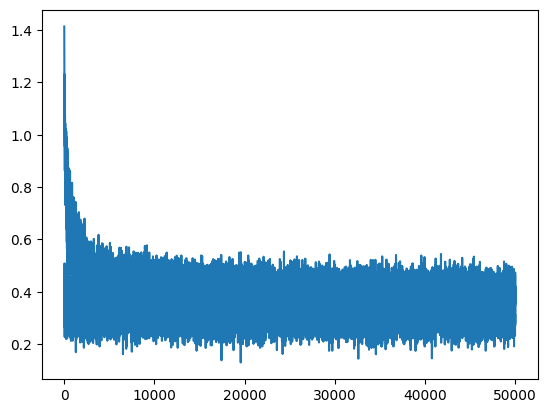

In [304]:
plt.plot(stepi, lossi)

In [305]:
emb = C[Xtr] 
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
train_loss = F.cross_entropy(logits, Ytr)

In [306]:
emb = C[Xdev] 
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
val_loss = F.cross_entropy(logits, Ydev)

In [307]:
train_loss, val_loss

(tensor(2.1792, grad_fn=<NllLossBackward0>),
 tensor(2.2014, grad_fn=<NllLossBackward0>))

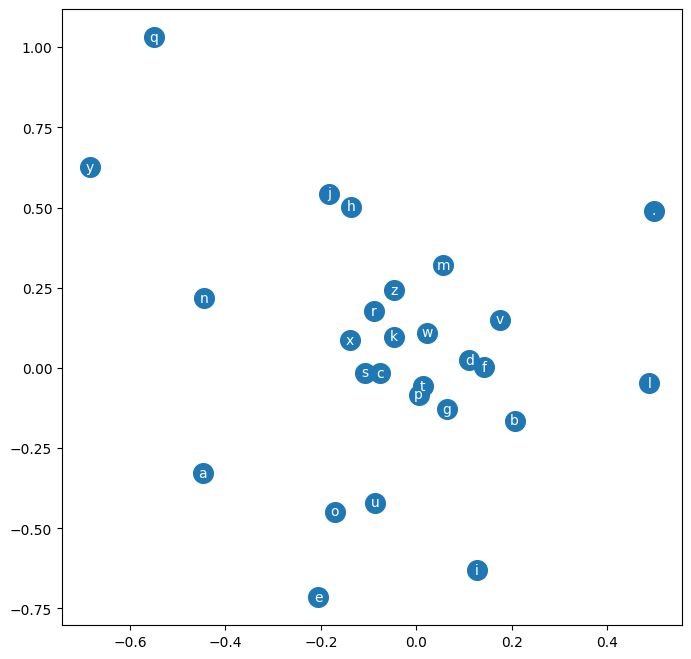

In [266]:
plt.figure(figsize=(8, 8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color="white")

In [309]:
g = torch.Generator().manual_seed(42)

for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor(context)]
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    print(''.join(itos[i] for i in out))

anukeen.
kis.
marian.
dan.
shan.
silaylen.
keman.
luvan.
emiah.
aden.
dizo.
kence.
jordin.
kalla.
mikonyn.
adhvihiana.
zalin.
tian.
tihan.
marotte.
